In [2]:
import os, sys
import numpy as np
import pandas as pd
import pickle as pk
import scipy as sp
import matplotlib.pyplot as plt
from matplotlib import cm
import matplotlib as mpl
from itertools import product
from scipy.optimize import curve_fit as cfit

sys.path.insert(0, '../scripts_analysis')
from analysis import *
from peaks import  detect_peaks

# plt.style.use('dark_background')
plt.rcParams.update(plt.rcParamsDefault)

dataPath = "/media/nishant/4tb/output/MFB/"
resultPath = "/home/nishant/lab/project_MFB/data/"
figPath = "/home/nishant/lab/project_MFB/plots/mechanism"

In [3]:
def get_conc_along_radius(simtype, tpoint, bins=np.arange(0,0.81,0.01), nseeds=500):
    df = pd.read_csv(os.path.join(resultPath, 'singleAZ', simtype, f'{tpoint:06.0f}.dat'), 
                     delimiter=' ', names=['x','y','z'])
    df['dist'] = np.sqrt(df['x']**2 + df['y']**2 + (df['z']+0.4)**2)

    # get count of ions in each shell
    counts, _ = np.histogram(df.dist, bins=bins)

    # get volume of each shell
    vol = np.zeros((len(counts)))
    for i in range(1,len(bins)):
        vol[i-1] = 2/3*np.pi*(bins[i]**3 - bins[i-1]**3)
        # print(bins[i], vol[i-1])

    # print(len(counts), len(_bins))

    return bins, counts/vol*0.00166/nseeds

bins, density = get_conc_along_radius('control', 2300)
# plt.plot(bins[5:], density[4:])

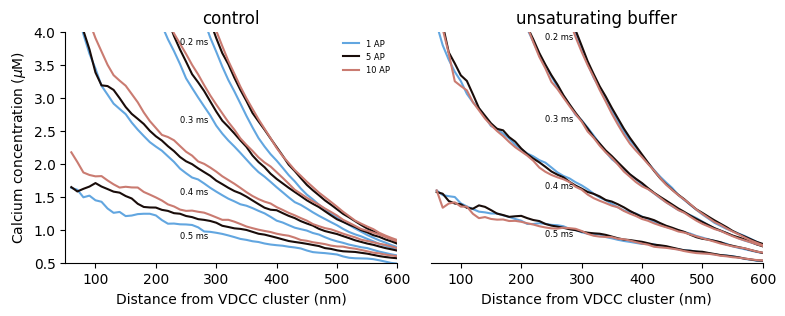

In [7]:
bins = np.arange(0,0.81,0.01)
stpoints = [2600, 82600, 182600]
tpoints = range(0, 301, 100)
APs = [1,5,10]
simtypes = {'control': 'control', 'unsaturating buffer': 'const_buffer'}#, 'no_buffer']

fig, axs = plt.subplots(1,len(simtypes), figsize=(9,3), sharex=True, sharey=True)
fig.subplots_adjust(wspace=0.1)
cmap = mpl.colormaps['berlin'] # 'viridis', 'managua', 'berlin'
lcolors = cmap(np.linspace(0.1, 0.9, len(stpoints)))

to_nm = 1000 # convert um to nm
for i,(key,simtype) in enumerate(simtypes.items()):
    for k,start in enumerate(stpoints):
        label = f'{APs[k]} AP'
        for j,tpoint in enumerate(tpoints):
            bins, density = get_conc_along_radius(simtype, start+tpoint, bins=bins)
            density = sp.signal.savgol_filter(density, 7, 3)
            axs[i].plot(bins[6:]*to_nm, density[5:], color=lcolors[k], label=label)
            label = None
            if not k:
                axs[i].text(bins[29]*to_nm-50, density[28]-0.1, f'{(tpoint+200)/1000:.1f} ms', fontsize=6)
    axs[i].set_title(key)
    axs[i].set_xlabel('Distance from VDCC cluster (nm)')

axs[0].set_ylabel(r'Calcium concentration ($\mu$M)')
axs[1].spines["left"].set_visible(False)
axs[0].legend(frameon=False, fontsize=6)
axs[1].tick_params(axis='y', size=0)
for ax in axs.ravel():
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.set_xlim(50, 600)
    ax.set_ylim(0.5,4)

fig.savefig(os.path.join(figPath, 'ca_domain.pdf'), dpi=300,
            bbox_inches='tight', transparent=True)
plt.show()

/tmp/ipykernel_6604/3116162466.py:26: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axs[1].legend(frameon=False, fontsize=6)


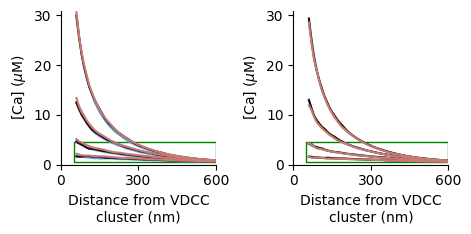

In [15]:
bins = np.arange(0,0.81,0.01)
stpoints = [2600, 82600, 182600]
tpoints = range(0, 301, 100)
APs = [1,5,10]
simtypes = {'control': 'control', 'const buffer conc.': 'const_buffer'}#, 'no_buffer']

fig, axs = plt.subplots(1,len(simtypes), figsize=(5,2), sharex=True)
fig.subplots_adjust(wspace=0.5)
cmap = mpl.colormaps['berlin'] # 'viridis', 'managua', 'berlin'
lcolors = cmap(np.linspace(0.1, 0.9, len(stpoints)))

for i,(key,simtype) in enumerate(simtypes.items()):
    for k,start in enumerate(stpoints):
        for j,tpoint in enumerate(tpoints):
            bins, density = get_conc_along_radius(simtype, start+tpoint, bins=bins)
            density = sp.signal.savgol_filter(density, 7, 3)
            axs[i].plot(bins[6:]*to_nm, density[5:], color=lcolors[k], label=label)

    axs[i].set_xlabel('Distance from VDCC\ncluster (nm)')

    ## make rectangle for zoomed in region
    rect = mpl.patches.Rectangle((50,0.5), 550, 4, linewidth=1, edgecolor='green', 
                                 facecolor='none')
    axs[i].add_patch(rect)

axs[1].legend(frameon=False, fontsize=6)
for ax in axs.ravel():
    ax.set_ylabel(r'[Ca] ($\mu$M)')
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.set_xlim(0, 600)
    ax.set_ylim(0,31)
    ax.set_xticks([0, 300, 600])
    ax.set_yticks([0, 10, 20, 30])

fig.savefig(os.path.join(figPath, 'ca_domain_inset.pdf'), dpi=300,
            bbox_inches='tight', transparent=True)
plt.show()